In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from scipy import stats
df_clean = pd.read_csv('../datasets/ENB2012_clean.csv')
print(df_clean.head())


   Relative Compactness  Surface Area  Wall Area  Roof Area  Overall Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing Area  Glazing Area Distribution  Heating Load  \
0            2           0.0                          0         15.55   
1            3           0.0                          0         15.55   
2            4           0.0                          0         15.55   
3            5           0.0                          0         15.55   
4            2           0.0                          0         20.84   

   Cooling Load  
0         21.33  
1         21.33  
2         21.33  
3         21.3

In [11]:
df_clean = pd.get_dummies(df_clean, columns = ['Orientation', 'Glazing Area Distribution'])

In [12]:
X = df_clean.drop(columns = ['Heating Load', 'Cooling Load'])
Y = df_clean[['Heating Load', 'Cooling Load']]

In [13]:
X = X.drop(columns = ['Roof Area', 'Surface Area'])
print(X.columns.tolist())

['Relative Compactness', 'Wall Area', 'Overall Height', 'Glazing Area', 'Orientation_2', 'Orientation_3', 'Orientation_4', 'Orientation_5', 'Glazing Area Distribution_0', 'Glazing Area Distribution_1', 'Glazing Area Distribution_2', 'Glazing Area Distribution_3', 'Glazing Area Distribution_4', 'Glazing Area Distribution_5']


In [14]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size = 0.2, random_state = 42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (614, 14), Test: (154, 14)


In [18]:
pd.concat([X_train, Y_train], axis = 1).to_csv('../datasets/train.csv', index = False)
pd.concat([X_test, Y_test], axis = 1).to_csv('../datasets/test.csv', index = False)
print('Saved')
                  

Saved


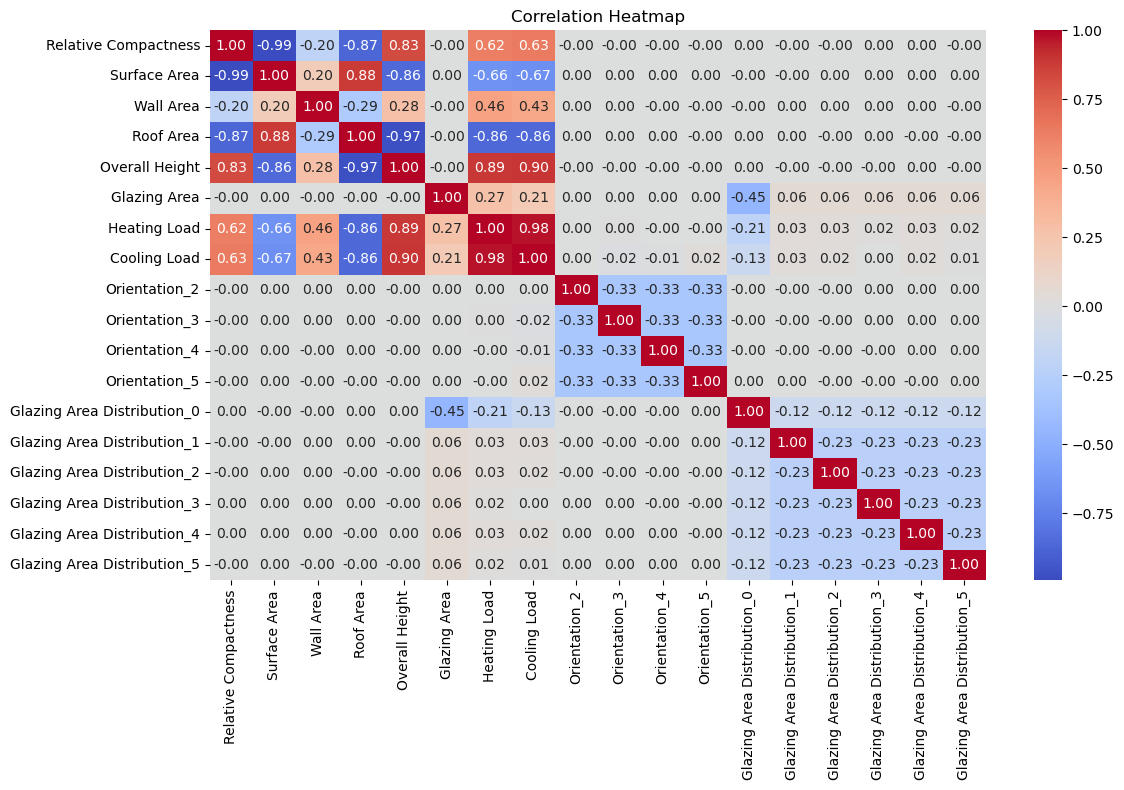

In [19]:
plt.figure(figsize=(12, 8))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()